In [ ]:
from paths import PROJECT_ROOT
import sys
sys.path.insert(0, PROJECT_ROOT)

import os
from connectome.visualization.activations_funcs import get_activation_dictionnary
from connectome.visualization.random_networks_plots.plot_config import apply_plot_style
from connectome.visualization.activations_funcs import get_all_connections
plots_dir = os.path.join(PROJECT_ROOT, "plots")
from connectome.visualization.random_networks_plots.plot_config import RANDOMIZATION_NAMES
NUM_PASSES = 3

apply_plot_style()

# Create plots directory if it doesn't exist
os.makedirs(plots_dir, exist_ok=True)


from connectome.data_helpers import load_neuron_coordinates

from joblib import Memory


cache_dir = os.path.join(PROJECT_ROOT, "notebooks", "visualization", "data", ".joblib_cache")
memory = Memory(location=cache_dir, verbose=0)


@memory.cache
def connections_cached():
    """Disk-cached version of get_all_connections()."""
    return get_all_connections()


@memory.cache
def activations_cached(num_passes: int = 4):
    """Disk-cached wrapper around get_activation_dictionnary()."""
    conn_dict = connections_cached()
    return get_activation_dictionnary(conn_dict, num_passes)

neuron_position_data = load_neuron_coordinates()

# Heavy cached computations
connections_dict = connections_cached()
activations_dict = activations_cached(NUM_PASSES)

# remove random pruned from both
_ = connections_dict.pop(RANDOMIZATION_NAMES["random_pruned"])
_ = activations_dict.pop(RANDOMIZATION_NAMES["random_pruned"])

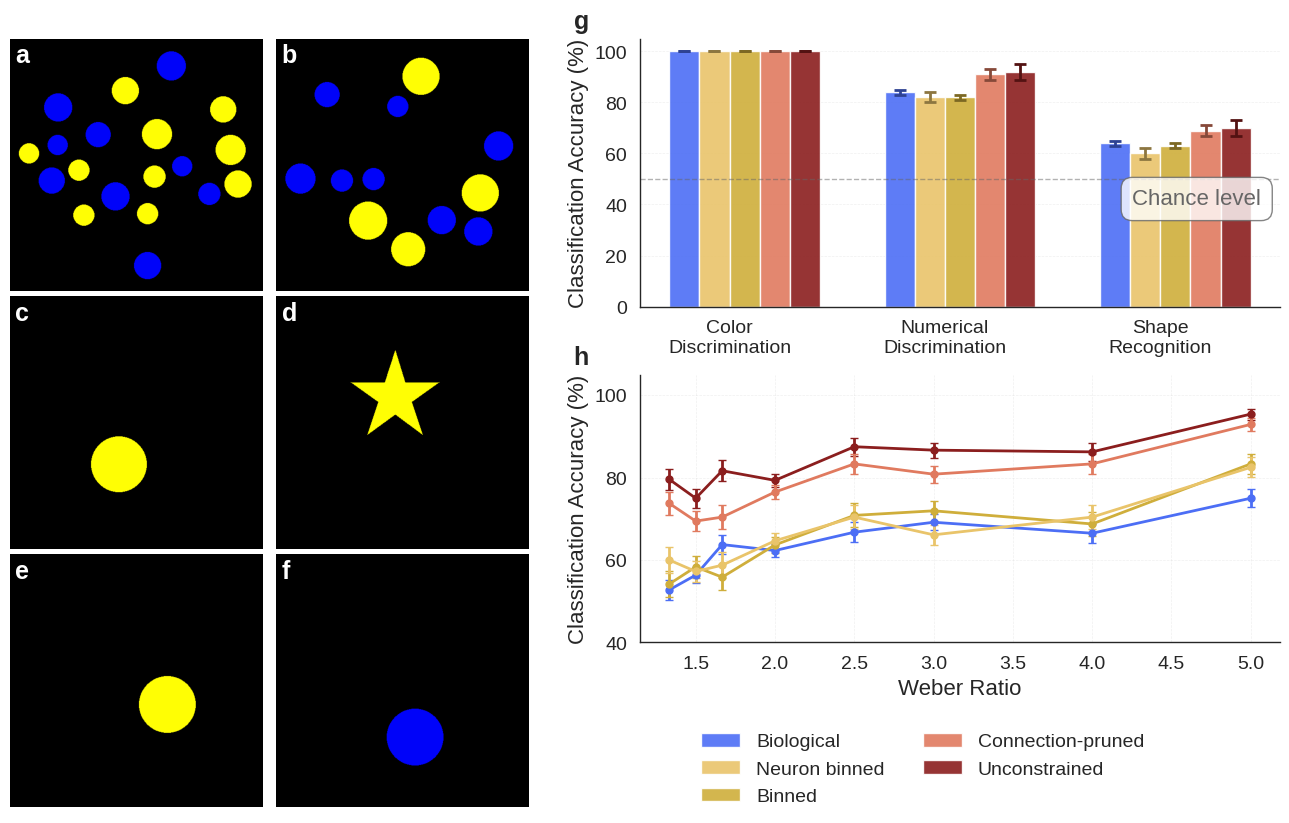

In [26]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.image import imread
import seaborn as sns

plt.close('all')
sns.set_theme(font_scale=1.4, style="white")

# Reload submodules and import directly from them
import importlib
from connectome.visualization import plot_config, models_accuracy
from connectome.visualization import plot_helpers as plots
importlib.reload(plot_config)
importlib.reload(models_accuracy)
importlib.reload(plots)
task_accuracy_comparison = models_accuracy.task_accuracy_comparison

apply_plot_style()
from connectome.visualization.random_networks_plots.plot_config import PLOT_STYLE_PARAMS

font_size = PLOT_STYLE_PARAMS["font.size"]

# Load task images
task_images_dir = os.path.join(PROJECT_ROOT, "figures", "task_images")
images = [imread(os.path.join(task_images_dir, f"t{i}.png")) for i in range(1, 7)]

# Create main figure with two subfigures side by side
fig = plt.figure(figsize=(13, 8))
subfigs = fig.subfigures(1, 2, width_ratios=[0.85, 1.15], wspace=0.01)

# LEFT SUBFIGURE: Task images (3 rows x 2 cols)
subfig_left = subfigs[0]
subfig_left.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02, hspace=0.02, wspace=0.02)
axs_left = subfig_left.subplots(3, 2)
ax_imgs = []
for i, ax in enumerate(axs_left.flat):
    ax.imshow(images[i])
    ax.axis('off')
    ax.set_aspect('equal')
    ax.text(0.02, 0.98, chr(ord('a') + i), transform=ax.transAxes, 
            fontsize=font_size, fontweight='bold', va='top', ha='left', color='white')
    ax_imgs.append(ax)

# RIGHT SUBFIGURE: Two plots + legend
subfig_right = subfigs[1]
subfig_right.subplots_adjust(left=0.12, right=0.98, top=0.98, bottom=0.08, hspace=0.35)
gs_right = GridSpec(3, 1, figure=subfig_right, height_ratios=[1, 1, 0.18], 
                    left=0.12, right=0.98, top=0.98, bottom=0.08, hspace=0.35)

# Plot g: task accuracy
ax_task = subfig_right.add_subplot(gs_right[0])
task_accuracy_comparison(ax=ax_task, show_legend=False, chance_fontsize=16)
ax_task.text(-0.08, 1.02, 'g', transform=ax_task.transAxes, 
             fontsize=font_size, fontweight='bold', va='bottom', ha='right')

# Plot h: weber
ax_weber = subfig_right.add_subplot(gs_right[1])
plots.plot_weber_by_randomization(
    folder=os.path.join(PROJECT_ROOT, "supplementary_data"),
    min_weber=1.2,
    ax=ax_weber,
    show_legend=False
)
ax_weber.text(-0.08, 1.02, 'h', transform=ax_weber.transAxes, 
              fontsize=font_size, fontweight='bold', va='bottom', ha='right')

# Shared legend in the bottom area of right subfigure
handles, labels = ax_task.get_legend_handles_labels()
subfig_right.legend(handles, labels, loc='lower center', ncol=2, frameon=False, fontsize=14)

plt.show()

fig.savefig(os.path.join(plots_dir, "figure_3.pdf"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(plots_dir, "figure_3.png"), dpi=300, bbox_inches='tight')